#### Setup

In [1]:
import os

import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision

import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from scipy.stats import binom

torch.set_printoptions(sci_mode=False)

In [2]:
%cd /home/atimans/Desktop/project_erc/erc

/home/atimans/Desktop/project_erc/erc


In [3]:
def savefig(dir, fname):
    path = os.path.join(os.path.dirname(os.getcwd()), 'plots', dir)
    os.makedirs(path, exist_ok=True)
    full_path = os.path.join(path, fname)
    plt.savefig(full_path, bbox_inches='tight')
    print('Figure saved under "%s"' % full_path)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Using custom CIFAR-10 pretrained model

These models are taken from [this github](https://github.com/huyvnphan/PyTorch_CIFAR10) and already trained on CIFAR-10, so they are useable off the shelf.

In [5]:
from PyTorch_CIFAR10.cifar10_models.resnet import resnet50

In [6]:
model = resnet50(pretrained=True)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# custom inference transforms for model (see github)
mean = [0.4914, 0.4822, 0.4465]
std = [0.2471, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# load datasets, and dataloaders with transforms
cifar10_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
cifar10_loader = DataLoader(cifar10_dataset, batch_size=64, shuffle=False)

svhn_dataset = datasets.SVHN(root='./data', split='test', transform=transform)
svhn_loader = DataLoader(svhn_dataset, batch_size=64, shuffle=False)

In [8]:
print("Final dataset shape:")
print(f"CIFAR-10: {len(cifar10_loader.dataset), cifar10_loader.dataset.__getitem__(0)[0].shape}")
print(f"SVHN: {len(svhn_loader.dataset), svhn_loader.dataset.__getitem__(0)[0].shape}")

print("\nNr of classes and type:")
print(f"CIFAR-10: {len(cifar10_dataset.classes), cifar10_dataset.classes}")
print(f"SVHN: {len(np.unique(svhn_dataset.labels)), np.unique(svhn_dataset.labels)}")

Final dataset shape:
CIFAR-10: (10000, torch.Size([3, 32, 32]))
SVHN: (26032, torch.Size([3, 32, 32]))

Nr of classes and type:
CIFAR-10: (10, ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])
SVHN: (10, array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))


In [9]:
# inference and collect predictions
def inference(loader, model):
    print(f"{len(loader.dataset) / loader.batch_size} batches of size {loader.batch_size}.")
    all_preds, all_conf = [], []
    
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Batch"):
            images = images.to(device)
            out = model(images).to('cpu')
            probs = nn.functional.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)
            conf = outlier_score(probs)
            
            all_preds.extend(preds.numpy())
            all_conf.extend(conf.numpy())

    return (
        np.array(all_preds, dtype=np.int32), 
        np.array(all_conf, dtype=np.float32)
    )
    
def outlier_score(probs):
    # top softmax (low top confidence = outlier)
    # score = 1 - torch.max(probs, axis=1)[0]
    
    # normalized entropy (high entropy = outlier)
    score = - torch.sum(probs * torch.log(probs + 1e-10), axis=1) / torch.log(torch.tensor(probs.shape[1]).float())
    
    return score

In [10]:
# run inference on CIFAR-10 (inlier) and SVHN (outlier)
print("Running inference on CIFAR-10 (inlier) dataset...")
cifar10_preds, cifar10_conf = inference(cifar10_loader, model)

print("Running inference on SVHN (outlier) dataset...")
svhn_preds, svhn_conf = inference(svhn_loader, model)

Running inference on CIFAR-10 (inlier) dataset...
156.25 batches of size 64.


Batch: 100%|██████████| 157/157 [00:04<00:00, 32.14it/s]


Running inference on SVHN (outlier) dataset...
406.75 batches of size 64.


Batch: 100%|██████████| 407/407 [00:10<00:00, 38.13it/s]


In [11]:
print(cifar10_preds.shape, cifar10_conf.shape, svhn_preds.shape, svhn_conf.shape)
cifar10_preds[:10], cifar10_conf[:10], svhn_preds[:10], svhn_conf[:10]

(10000,) (10000,) (26032,) (26032,)


(array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1], dtype=int32),
 array([0.04088298, 0.04695556, 0.0521585 , 0.04220984, 0.03846278,
        0.03930046, 0.04144964, 0.03868615, 0.03988957, 0.1317654 ],
       dtype=float32),
 array([3, 3, 3, 5, 3, 3, 5, 0, 3, 5], dtype=int32),
 array([0.40998998, 0.10691661, 0.62084115, 0.5790672 , 0.68884945,
        0.4737729 , 0.12189494, 0.36792052, 0.55023474, 0.04050966],
       dtype=float32))

In [12]:
# compute basic metrics
cifar10_accuracy = (cifar10_preds == cifar10_dataset.targets).mean()
svhn_accuracy = (svhn_preds == svhn_dataset.labels).mean()
print(f"CIFAR-10 accuracy: {cifar10_accuracy:.4f}")
print(f"SVHN accuracy: {svhn_accuracy:.4f}")

print(f"CIFAR-10 mean outlier score: {cifar10_conf.mean():.4f}")
print(f"SVHN mean outlier score: {svhn_conf.mean():.4f}")

CIFAR-10 accuracy: 0.9365
SVHN accuracy: 0.1036
CIFAR-10 mean outlier score: 0.0813
SVHN mean outlier score: 0.2791


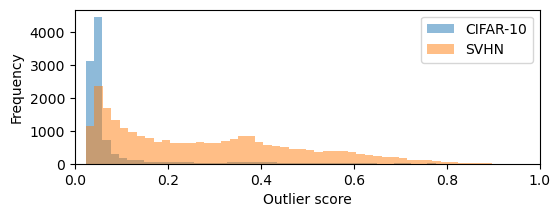

In [13]:
# plot histograms of outlier scores
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10", density=False)
plt.hist(svhn_conf, bins=50, alpha=0.5, label="SVHN", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

#### Risk control via LTT

Learn-then-Test to determine an outlier threshold $\psi \in [0,1]$ with risk control.

In [14]:
def thresh_grid(min, max, step):
    """Create a grid of threshold values.

    Args:
        min (float): Minimum grid value.
        max (float): Maximum grid value.
        step (float): Step size between grid values.

    Returns:
        torch.Tensor: Grid of threshold values.
    """
    threshs = torch.arange(max, min, -step, dtype=torch.float)
    # every thresh has at most the same number of decimal points as step
    threshs = torch.round(threshs / step) * step
    return threshs


def hb_p_value(risk, n, eps, binary_loss: bool):
    """Compute the p-value of the Hoeffding-Bentkus bound. If binary loss, use the binomial CDF directly.
    Adapted from https://github.com/aangelopoulos/ltt/blob/main/core/bounds.py

    Args:
        risk: Computed risk estimate.
        n: Number of calibration samples.
        eps: Tolerated risk level.

    Returns:
        p-value.
    """
    if binary_loss:
        p_value = binom.cdf(np.ceil(n * risk), n, eps)
    else:
        bentkus_p_value = np.e * binom.cdf(np.ceil(n * risk), n, eps)
        a, b = min(risk, eps), eps
        h1 = a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))
        hoeffding_p_value = np.exp(-n * h1)
        p_value = min(bentkus_p_value, hoeffding_p_value)

    assert 0 - 1e-4 <= p_value <= 1 + 1e-4, "p-value must be in [0, 1]: {}".format(p_value)
    return p_value


def get_ltt_thresh(losses, eps, delta, binary_loss=False, loss_B=1.0):
    # losses: (N_thresh, N_cal)
    # select thresh closest s.t. LTT p-value is controlled on calibration data
    
    # Note that LTT requires losses in [0, 1], thus we first need to rescale the losses if loss_B > 1
    losses = torch.max(torch.zeros_like(losses), (1 / loss_B) * losses)
    
    N_thresh, N_cal = losses.shape
    risk = losses.mean(dim=1) # (N_thresh,)
    
    pval = torch.zeros((N_thresh,))
    for i in range(N_thresh):
        pval[i] = torch.tensor([hb_p_value(risk[i].item(), N_cal, eps, binary_loss)])
    
    thresh_ids = (pval <= delta).nonzero(as_tuple=True)[0]
    if thresh_ids.shape[0] == 0: # no accept
        thresh_id = torch.tensor([0])
        thresh_ids = torch.tensor([0])
    else:
        thresh_id = thresh_ids[-1] # smallest thresh (from below)
    return thresh_id, thresh_ids, pval


In [15]:
# Define a grid of outlier threshold candidates in the range [0, 1]
thresh_cand = thresh_grid(0, 1, 0.01)
thresh_cand

tensor([1.0000, 0.9900, 0.9800, 0.9700, 0.9600, 0.9500, 0.9400, 0.9300, 0.9200,
        0.9100, 0.9000, 0.8900, 0.8800, 0.8700, 0.8600, 0.8500, 0.8400, 0.8300,
        0.8200, 0.8100, 0.8000, 0.7900, 0.7800, 0.7700, 0.7600, 0.7500, 0.7400,
        0.7300, 0.7200, 0.7100, 0.7000, 0.6900, 0.6800, 0.6700, 0.6600, 0.6500,
        0.6400, 0.6300, 0.6200, 0.6100, 0.6000, 0.5900, 0.5800, 0.5700, 0.5600,
        0.5500, 0.5400, 0.5300, 0.5200, 0.5100, 0.5000, 0.4900, 0.4800, 0.4700,
        0.4600, 0.4500, 0.4400, 0.4300, 0.4200, 0.4100, 0.4000, 0.3900, 0.3800,
        0.3700, 0.3600, 0.3500, 0.3400, 0.3300, 0.3200, 0.3100, 0.3000, 0.2900,
        0.2800, 0.2700, 0.2600, 0.2500, 0.2400, 0.2300, 0.2200, 0.2100, 0.2000,
        0.1900, 0.1800, 0.1700, 0.1600, 0.1500, 0.1400, 0.1300, 0.1200, 0.1100,
        0.1000, 0.0900, 0.0800, 0.0700, 0.0600, 0.0500, 0.0400, 0.0300, 0.0200,
        0.0100])

In [16]:
# Select a random subset of fixed size from the inlier data as calibration set
n_cal = int(0.1 * len(cifar10_preds))
cal_idx = torch.randperm(len(cifar10_preds))[:n_cal]
print(f"Using {n_cal} calibration samples.")
print(cal_idx[:10])

Using 1000 calibration samples.
tensor([4365, 6906, 8750, 1044, 5880, 9745, 5950, 7614, 2334, 1226])


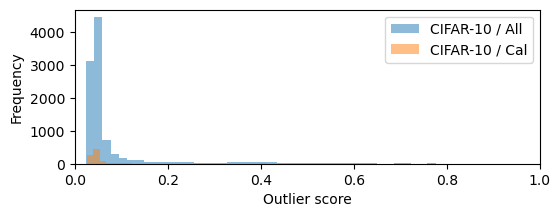

In [17]:
# assert that the calibration set is representative
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10 / All", density=False)
plt.hist(cifar10_conf[cal_idx], bins=50, alpha=0.5, label="CIFAR-10 / Cal", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

Consider the risk as the total error rate $TER = \frac{\# FP + \# FN}{\# data}$. This could be a relevant risk because it incorporates both inlier and outlier misclassification, whereas something like the FPR only concerns inlier data. But, in the case of only inlier data (as for calibration data) the TER is equal to the $FPR(\mathcal{D}_{cal}) = \frac{\#{FP}}{N_{cal}} \in [0,1]$, and a calibration sample $i$ is classified as $FP$ if its outlier score $out_i > \psi$ since all calibration samples are known to be in-distribution (so there are no FN, i.e., labelling outlier as inlier).

In [18]:
# collect losses in a grid of size (N_thresh, N_cal)

def get_loss(thresh, conf):
    return (conf > thresh)

def get_losses(thresh_cand, conf):
    n_thresh, n_cal = thresh_cand.shape[0], conf.shape[0]
    losses = torch.zeros((n_thresh, n_cal))
    
    for i, thresh in enumerate(thresh_cand):
        losses[i] = get_loss(thresh, conf).to(torch.float32)
    
    return losses

In [19]:
eps = 0.1 # risk level
delta = 0.1 # significance level

losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[cal_idx]))
risk = losses.mean(dim=1)
thresh_id, thresh_ids, pval = get_ltt_thresh(losses, eps, delta, binary_loss=True)

print(f"Selected threshold: {thresh_cand[thresh_id]}, p-value: {pval[thresh_id]}, risk: {risk[thresh_id]}")

Selected threshold: 0.1899999976158142, p-value: 0.09192916005849838, risk: 0.08699999749660492


In [20]:
# visualize risk control decision
def plot_thresh_risk_pval(thresh, risk, pval, rc_psi, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the risk and p-value as a function of thresh.
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
    ax1.plot(thresh, risk, color="black")
    ax1.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax1.set_xlabel(r"Threshold parameter $\psi$")
    ax1.set_ylabel("Risk")
    ax1.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax1.axvline(
        x=rc_psi, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax1.legend()

    ax2.plot(thresh, pval, color="black")
    ax2.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax2.set_xlabel(r"Threshold parameter $\psi$")
    ax2.set_ylabel("P-value")
    ax2.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax2.axvline(
        x=rc_psi, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax2.legend()

    fig.suptitle(rf"Target guarantee: $\epsilon={epsilon}$, $\delta={delta}$")
    # fname = "thresh_risk_pval.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()


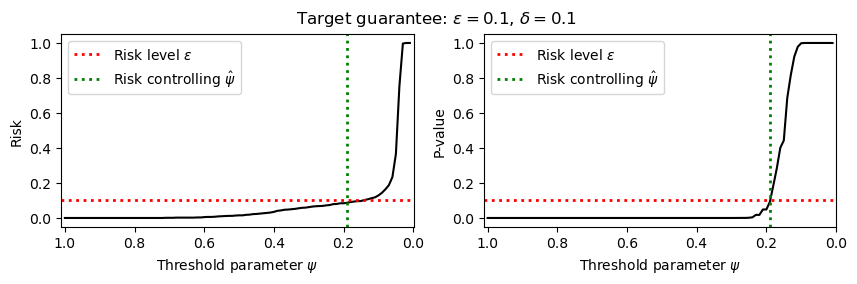

In [21]:
plot_thresh_risk_pval(thresh_cand, risk, pval, thresh_cand[thresh_id], eps, delta)

In [22]:
# Check the selected threshold on the test set
cifar10_test_idx = ~torch.isin(torch.arange(len(cifar10_preds)), cal_idx)
test_losses = get_losses(thresh_cand, torch.Tensor(cifar10_conf)[cifar10_test_idx])
test_risk = test_losses.mean(dim=1)

print(f"Test risk: {test_risk[thresh_id]}")

Test risk: 0.08799999952316284


In [23]:
def plot_test_risk(risk, losses, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the test risk and loss statistics.
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.hist(
        losses,
        bins=30,
        density=True,
        color="lightgray",
        edgecolor="black",
        linewidth=1,
        alpha=0.8,
    )
    ax.set_ylabel("Density")
    ax.set_xlabel("Test losses")
    ax.set_xlim(-0.03, 1.03)
    ax.axvline(x=epsilon, color="red", ls="-", label=r"Risk level $\epsilon$", lw=2)
    ax.axvline(
        x=risk,
        color="green",
        ls="-",
        label=f"Test risk: {risk:.3f}",
        lw=2,
    )
    ax.legend()
    fig.suptitle("Risk control on test data")
    # fname = "test_risk.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()

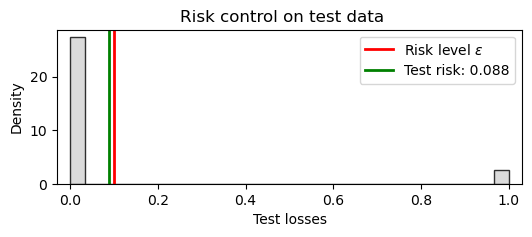

In [24]:
plot_test_risk(test_risk[thresh_id], test_losses[thresh_id], eps, delta)

#### Test stream setting

Build wealth process $W_T = \prod_{t=1}^{T} E_t$ with betting scores $E_t = 1 + \lambda_t \cdot (\ell_{\psi}(X_t, Y_t) - \epsilon)$ and $W_0 = 1$.

In [25]:
cifar10_test_idx = ~torch.isin(torch.arange(len(cifar10_preds)), cal_idx)
cifar10_test_labels = torch.Tensor(cifar10_dataset.targets)[cifar10_test_idx]
cifar10_test_preds = torch.Tensor(cifar10_preds)[cifar10_test_idx]
cifar10_test_conf = torch.Tensor(cifar10_conf)[cifar10_test_idx]
id_size = cifar10_test_labels.shape[0]

svhn_test_labels = torch.Tensor(svhn_dataset.labels)
svhn_test_preds = torch.Tensor(svhn_preds)
svhn_test_conf = torch.Tensor(svhn_conf)
ood_size = svhn_test_labels.shape[0]

print("Test set sizes:")
print(f"CIFAR-10: {id_size}")
print(f"SVHN: {ood_size}")

Test set sizes:
CIFAR-10: 9000
SVHN: 26032


In [144]:
def get_id(idx):
    return cifar10_test_labels[idx], cifar10_test_preds[idx], cifar10_test_conf[idx]


def get_ood(idx):
    return svhn_test_labels[idx], svhn_test_preds[idx], svhn_test_conf[idx]


# get loss for all psi candidates for one sample
def get_loss(loss_type, psi_cand, bern, lab, pred, conf):
    if loss_type == "outlier_fpr_fnr":
        if bern == 0:
            psi_loss = (conf > psi_cand) # false positive
        else:
            psi_loss = (conf <= psi_cand) # false negative
   
    elif loss_type == "outlier_fnr":
        if bern == 0:
            psi_loss = torch.zeros_like(psi_cand) # no penalty for false positive
        else:
            psi_loss = (conf <= psi_cand) # false negative
    
    elif loss_type == "outlier_fpr":
        if bern == 0:
            psi_loss = (conf > psi_cand) # false positive
        else:
            psi_loss = torch.zeros_like(psi_cand) # no penalty for false negative
    
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")
    
    return psi_loss.to(torch.float32)


# get risk for all psi candidates for one time step
def get_risk(loss_type, losses, bern, t):
        if loss_type == "outlier_fpr_fnr":
            risk = losses[:t+1, :].mean(dim=0)
        
        elif loss_type == "outlier_fnr":
            nr_out = bern[:t+1, :].sum() + 1e-10
            risk = losses[:t+1, :].mean(dim=0) / nr_out
        
        elif loss_type == "outlier_fpr":
            batch_size = bern.shape[-1]
            nr_in = ((t * batch_size) - bern[:t+1, :].sum()) + 1e-10
            risk = losses[:t+1, :].mean(dim=0) / nr_in
        
        else:
            raise ValueError(f"Unknown loss type: {loss_type}")
        
        return risk


# get bet for e-process for one time step
def get_bet(betting_type, eps, losses, t, burn_in=0, lookback=30):
    t_start = max(t - lookback, 0)
    
    if betting_type == "unit_bet":
        bet = torch.ones_like(losses[t]) # (psi_size,)
    
    elif betting_type == "aGRAPA": # see https://arxiv.org/pdf/2010.09686, sec B.3
        mu = losses[t_start:t].mean(dim=0) + 1e-10
        var = losses[t_start:t].var(dim=0) + 1e-10
        c = 0.5 # constant, recommended 0.5 or 0.75
        term = (mu - eps) / (var + (mu - eps)**2) + 1e-10
        bet = torch.max(torch.tensor(0), torch.min(term, torch.tensor(c/eps)))
    
    elif betting_type == "GRAPA": # see https://arxiv.org/pdf/2010.09686, sec B.2
        lam_cand = torch.arange(0.1, (1/eps), 0.1)
        psi_size = losses.shape[-1]
        lam_growth = torch.ones((len(lam_cand), psi_size))
        for l, lam in enumerate(lam_cand):
            growth = torch.log(torch.ones(psi_size) + lam * (losses[t_start:t] - eps))
            lam_growth[l, :] = torch.mean(growth, dim=0)
        bet = lam_cand[lam_growth.argmax(dim=0)]
        
    else:
        raise ValueError(f"Unknown betting type: {betting_type}")
    
    if t < burn_in:
        bet = torch.zeros_like(bet)
    
    return bet


# check stopping condition of the e-process for all psi candidates for one time step
def check_stop_time_eprocess(stop_time, e_process, delta, t, T):
    null_rejections = torch.where(e_process >= 1/delta)[0]
    
    if len(null_rejections) > 0:
        null_rejections_new = null_rejections[stop_time[null_rejections] == -1] # new rejections (not yet stopped)
        
        if len(null_rejections_new) > 0: 
            # print(f"New null rejections at time {t}: {null_rejections_new.tolist()}")
            stop_time[null_rejections_new] = t

    if t == T: # At the final time step, assign T to any index still marked as "not stopped"
        stop_time[stop_time == -1] = T
    
    return stop_time


# check stopping condition of the empirical risk for all psi candidates for all time steps 
def check_stop_time_emp_risk(stop_time, risk, eps, T, burn_in=100, lookback=30):
    for psi in range(len(stop_time)):
        null_rejections = torch.where(risk[:, psi] >= eps)[0]
        robust_null_rejections = null_rejections[null_rejections >= burn_in] # ignore burn-in period crossings
        
        if len(robust_null_rejections) >= lookback: # if enough crossings, check for robust first sequence of `lookback` consecutive integers
            for i in range(len(robust_null_rejections) - lookback + 1):
                if torch.all(robust_null_rejections[i:i + lookback] == torch.arange(robust_null_rejections[i], robust_null_rejections[i] + lookback)):
                    stop_time[psi] = robust_null_rejections[i] # this is a robust crossing
                    break
        elif len(robust_null_rejections) > 0: # if no robust sequence or not enough crossings, stop at the first crossing
            stop_time[psi] = robust_null_rejections[0]
        else:
            stop_time[psi] = T # if no crossings, stop at the final time step
    
    return stop_time


# get the set of valid psi candidates for one time step and return the selected psi
def get_valid_psi(stop_time, psi_cand, psi_selection="min"):
    # assert psi_cand.shape[0] == stop_time.shape[0], "Number of psi candidates and stop times must match."
    valid_psi = psi_cand[torch.where(stop_time == -1)[0]] # not yet stopped
    
    if len(valid_psi) > 0:
        if psi_selection == "min":
            select_psi = valid_psi.min()
        elif psi_selection == "max":
            select_psi = valid_psi.max()
        else:
            raise ValueError(f"Unknown psi selection: {psi_selection}")
    else: # default to some "trivial safe zone"
        select_psi = torch.ones(1)
    
    return select_psi, valid_psi.tolist()


# count the false alarms for all psi candidates for one trial
def count_false_alarm(false_alarms, stop_time_eprocess, stop_time_risk):
    early_stops = torch.where((stop_time_eprocess - stop_time_risk) < 0)[0]
    false_alarms[early_stops] = 1
    return false_alarms

In [145]:
eps = 0.1 # risk level (should be the same as for calibration if done)
delta = 0.1 # significance level
T = 2000 # nr of time steps
T_ood = 200 # ood fraction increase every T_ood steps
B = 10 # batch size at each time step
R = 10 # nr of repeated trials
burn_in = int(100/B) # burn-in period for the e-process and empirical risk
lookback = 30 # lookback period for the empirical risk and bets

ood_probs = np.arange(0.05, 1.0, 0.1)
psi_cand = torch.arange(0, 1.01, 0.01)
psi_start = thresh_cand[thresh_id].unsqueeze(0)
psi_size = psi_cand.shape[0]
loss_type = "outlier_fpr_fnr" # loss type for the stream
betting_type = "aGRAPA" # betting type for the e-process

stream_bern = torch.zeros((R, T, B)) # (Trial, Time, Batch)
stream_loss = torch.zeros((R, T, psi_size)) # (Trial, Time, Psi)
stream_risk = torch.zeros((R, T, psi_size)) # (Trial, Time, Psi)
stop_time_risk = torch.full((R, psi_size), -1.0) # (Trial, Psi)

stream_bets = torch.zeros((R, T, psi_size))
stream_eval = torch.ones((R, T, psi_size))
stream_eprocess = torch.ones((R, T, psi_size))
stop_time_eprocess = torch.full((R, psi_size,), -1.0)

psi_select = torch.zeros((R, T)) # selected threshold at each time step
psi_cs = [[[] for _ in range(T)] for _ in range(R)] # access as psi_cs[r][t]
psi_cs_size = torch.zeros((R, T))
false_alarms = torch.zeros((R, psi_size))
detection_delay = torch.zeros((R, psi_size))

print("--- Stream settings ---")
print(f"Risk level: {eps}")
print(f"Significance level: {delta}")
print(f"Nr of time steps: {T}")
print(f"OOD fraction increase every {T_ood} steps: {ood_probs}")
print(f"Batch size: {B}")
print(f"Nr of repeated trials: {R}")
print(f"Threshold candidates: {psi_size}")
print(f"Start threshold: {psi_start}")
print(f"Loss type: {loss_type}")
print(f"Betting type: {betting_type}")
print("\n--- Variable storage ---")
print(f"Stream Bernoulli: {stream_bern.shape}")
print(f"Stream Loss: {stream_loss.shape}")
print(f"Stream Risk: {stream_risk.shape}")
print(f"Stream Bets: {stream_bets.shape}")
print(f"Stream E-values: {stream_eval.shape}")
print(f"Stream E-process: {stream_eprocess.shape}")
print(f"Stop time trackers: {stop_time_risk.shape}")
print(f"Selected threshold: {psi_select.shape}")
print(f"Threshold CIs: {psi_cs}")
print(f"Threshold CI sizes: {psi_cs_size.shape}")
print(f"False alarms: {false_alarms.shape}")
print(f"Detection delays: {detection_delay.shape}")

--- Stream settings ---
Risk level: 0.1
Significance level: 0.1
Nr of time steps: 2000
OOD fraction increase every 200 steps: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Batch size: 10
Nr of repeated trials: 10
Threshold candidates: 101
Start threshold: tensor([0.1900])
Loss type: outlier_fpr_fnr
Betting type: aGRAPA

--- Variable storage ---
Stream Bernoulli: torch.Size([10, 2000, 10])
Stream Loss: torch.Size([10, 2000, 101])
Stream Risk: torch.Size([10, 2000, 101])
Stream Bets: torch.Size([10, 2000, 101])
Stream E-values: torch.Size([10, 2000, 101])
Stream E-process: torch.Size([10, 2000, 101])
Stop time trackers: torch.Size([10, 101])
Selected threshold: torch.Size([10, 2000])
Threshold CIs: [[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []

In [146]:
print("\n--- Running test stream ---")

for r in range(R):
    ood_idx = 0
    ood_prob = ood_probs[ood_idx]    

    for t in tqdm(range(T), desc=f"Trial {r+1}, Time step", leave=False):
        
        # increase OOD fraction every T_ood steps
        if (t > 0) and (t % T_ood == 0) and (t < len(ood_probs) * T_ood):
            # print(f"Time step {t}, OOD prob {ood_prob:.2f} -> {ood_probs[ood_idx+1]:.2f}")
            ood_idx += 1
            ood_prob = ood_probs[ood_idx]
        
        # prepare batch storage and get bets
        batch_loss = torch.zeros((B, psi_size))
        batch_eval = torch.zeros((B, psi_size))
        stream_bets[r, t, :] = get_bet(betting_type, eps, stream_loss[r], t, burn_in=burn_in, lookback=t)
        
        for b in range(B):
        
            # draw sample (id or ood)
            bern = np.random.binomial(1, ood_prob)
            if bern == 0:
                lab, pred, conf = get_id(idx=np.random.randint(0, id_size))
            else:
                lab, pred, conf = get_ood(idx=np.random.randint(0, ood_size))
            
            # compute batch-level loss and e-values
            stream_bern[r, t, b] = bern
            batch_loss[b, :] = get_loss(loss_type, psi_cand, bern, lab, pred, conf)
            batch_eval[b, :] = 1.0 + stream_bets[r, t, :] * (batch_loss[b, :] - eps)
        
        # aggregate over batches
        stream_loss[r, t, :] = batch_loss.mean(dim=0)
        stream_eval[r, t, :] = batch_eval.mean(dim=0)
        
        # get risk and e-process
        stream_risk[r, t, :] = get_risk(loss_type, stream_loss[r], stream_bern[r], t)
        if t == 0:
            stream_eprocess[r, t, :] = torch.ones_like(stream_eval[r, t, :])
        else:
            stream_eprocess[r, t, :] = stream_eprocess[r, t-1, :] * stream_eval[r, t, :]
        
        # check stopping times and build psi-CI
        stop_time_eprocess[r] = check_stop_time_eprocess(stop_time_eprocess[r], stream_eprocess[r, t], delta, t, T)
        psi_select[r, t], valid_psi = get_valid_psi(stop_time_eprocess[r], psi_cand, psi_selection="min")
        psi_cs[r][t].append(valid_psi)
        psi_cs_size[r, t] = len(valid_psi)
        
        del batch_loss, batch_eval, lab, pred, conf, bern, valid_psi

    # update per-trial metrics: detection delay, false alarm rates
    stop_time_risk[r] = check_stop_time_emp_risk(stop_time_risk[r], stream_risk[r], eps, T, burn_in=burn_in, lookback=lookback)
    false_alarms[r] = count_false_alarm(false_alarms[r], stop_time_eprocess[r], stop_time_risk[r])
    detection_delay[r] = (stop_time_eprocess[r] - stop_time_risk[r]).clip(min=0)



--- Running test stream ---


#### Evaluation & Figures

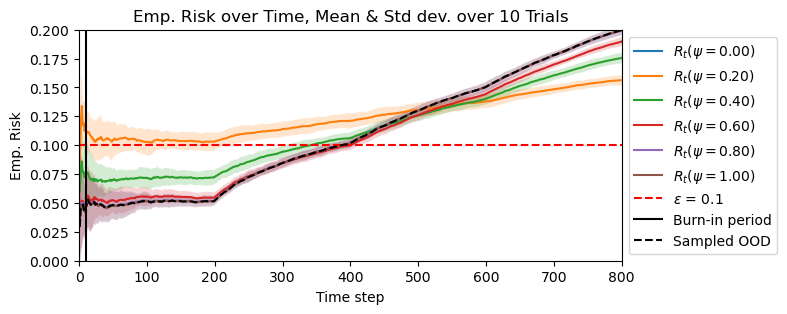

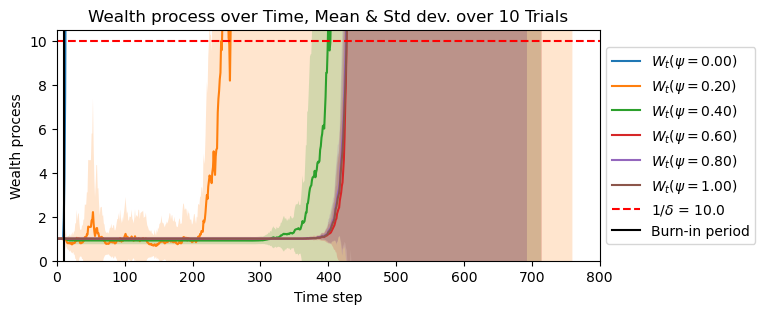

In [147]:
fixed_psi = torch.arange(0, 101, 20)

# RISK PLOT
plt.figure(figsize=(7, 3))
for f_p in fixed_psi:
    risk_mean = stream_risk[:, :, f_p].mean(dim=0).numpy()
    risk_std = stream_risk[:, :, f_p].std(dim=0).numpy()
    plt.plot(risk_mean, label=fr"$R_t(\psi = {psi_cand[f_p]:.2f})$")
    plt.fill_between(range(T), 
        risk_mean - risk_std, 
        risk_mean + risk_std, 
        alpha=0.2
    )
    
plt.axhline(eps, color='red', linestyle='--', label=rf"$\epsilon$ = {eps}")
plt.axvline(burn_in, color='black', linestyle='-', label="Burn-in period")
plt.plot(torch.cumsum(stream_bern.mean(dim=0).sum(dim=-1), 0) / (torch.arange(1, T+1) * B + 1e-10), label="Sampled OOD", color='black', linestyle='--')

plt.title(f"Emp. Risk over Time, Mean & Std dev. over {R} Trials")
plt.xlabel("Time step")
plt.ylabel("Emp. Risk")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlim(0, 800)
plt.ylim(0, 0.2)

# savefig("batch_50", "risk_over_time")
plt.show()

##############################################################################################
# E-PROCESS PLOT
plt.figure(figsize=(7, 3))
for f_p in fixed_psi:
    eprocess_mean = stream_eprocess[:, :, f_p].mean(dim=0).numpy()
    eprocess_std = stream_eprocess[:, :, f_p].std(dim=0).numpy()
    plt.plot(eprocess_mean, label=fr"$W_t(\psi = {psi_cand[f_p]:.2f})$")
    plt.fill_between(range(T), 
        eprocess_mean - eprocess_std, 
        eprocess_mean + eprocess_std, 
        alpha=0.2
    )

plt.axhline(1/delta, color='red', linestyle='--', label=rf"$1/\delta$ = {1/delta}")
plt.axvline(burn_in, color='black', linestyle='-', label="Burn-in period")

plt.title(f"Wealth process over Time, Mean & Std dev. over {R} Trials")
plt.xlabel("Time step")
plt.ylabel("Wealth process")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlim(0, 800)
plt.ylim(0, 1/delta+0.5)
# plt.ylim(0, 2)

# savefig("batch_50", "wealth_over_time")
plt.show()

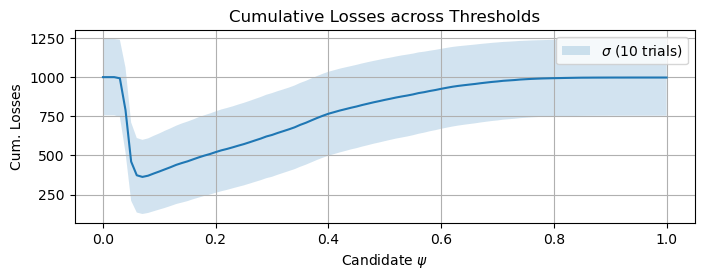

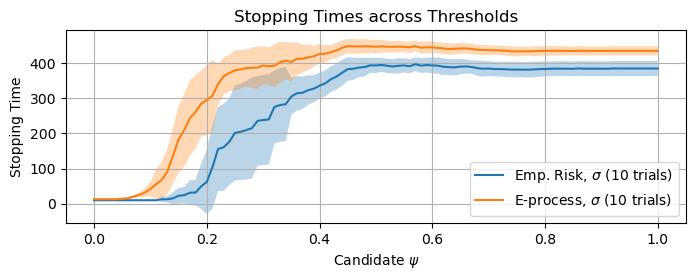

In [148]:
plt.figure(figsize=(8, 2.5))
loss_mean = stream_loss.mean(dim=0).sum(dim=0).numpy()
loss_std = stream_loss.std(dim=0).sum(dim=0).numpy()
plt.plot(psi_cand, loss_mean)
plt.fill_between(psi_cand, 
        loss_mean - loss_std, 
        loss_mean + loss_std, 
        alpha=0.2, label=rf"$\sigma$ ({R} trials)"
    )

plt.xlabel(r"Candidate $\psi$")
plt.ylabel("Cum. Losses")
plt.title("Cumulative Losses across Thresholds")
plt.grid(True)
plt.legend()

##############################################################################################
# STOPPING TIME PLOT

# Create a single figure and axis
fig, ax = plt.subplots(figsize=(8, 2.5))

# Calculate mean and standard deviation for empirical risk stopping times
stop_risk_mean = stop_time_risk.mean(dim=0)
stop_risk_std = stop_time_risk.std(dim=0)

# Plot empirical risk stopping time with shading
ax.plot(psi_cand, stop_risk_mean, label=rf"Emp. Risk, $\sigma$ ({R} trials)")
ax.fill_between(
    psi_cand,
    stop_risk_mean - stop_risk_std,
    stop_risk_mean + stop_risk_std,
    alpha=0.3,
)

# Calculate mean and standard deviation for E-process stopping times
stop_eprocess_mean = stop_time_eprocess.mean(dim=0)
stop_eprocess_std = stop_time_eprocess.std(dim=0)

# Plot E-process stopping time with shading
ax.plot(psi_cand, stop_eprocess_mean, label=rf"E-process, $\sigma$ ({R} trials)")
ax.fill_between(
    psi_cand,
    stop_eprocess_mean - stop_eprocess_std,
    stop_eprocess_mean + stop_eprocess_std,
    alpha=0.3,
)

# Label the axes and add a title
ax.set_xlabel(r"Candidate $\psi$")
ax.set_ylabel("Stopping Time")
ax.set_title("Stopping Times across Thresholds")

# Add grid and legend
ax.grid(True)
ax.legend()

# savefig("batch_10", "stoptimes_over_thresh_betwithwindow")
plt.show()

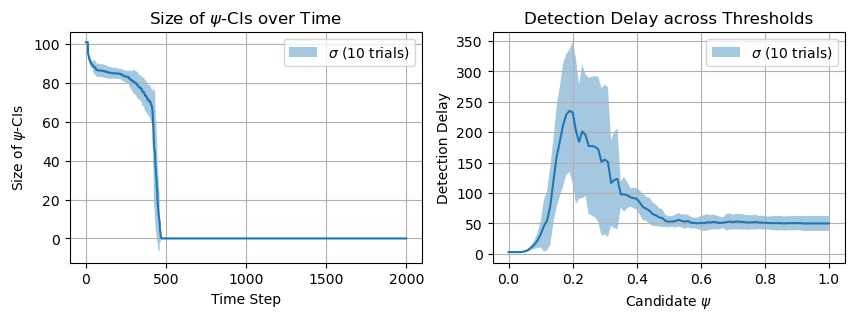

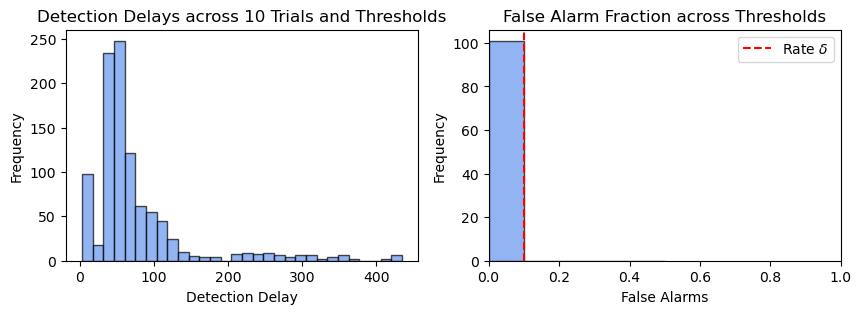

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Plot psi-CS size on the first subplot with standard deviation shading
psi_cs_mean = psi_cs_size.mean(dim=0)
psi_cs_std = psi_cs_size.std(dim=0)

axes[0].plot(psi_cs_mean)
axes[0].fill_between(
    range(psi_cs_mean.size(0)), 
    psi_cs_mean - psi_cs_std, 
    psi_cs_mean + psi_cs_std, 
    alpha=0.4, label=rf"$\sigma$ ({R} trials)"
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel(r"Size of $\psi$-CIs")
axes[0].set_title(r"Size of $\psi$-CIs over Time")
axes[0].grid(True)
axes[0].legend()

# Plot detection delay on the second subplot with standard deviation shading
detection_delay_mean = detection_delay.mean(dim=0)
detection_delay_std = detection_delay.std(dim=0)

axes[1].plot(psi_cand, detection_delay_mean)
axes[1].fill_between(
    psi_cand, 
    detection_delay_mean - detection_delay_std, 
    detection_delay_mean + detection_delay_std, 
    alpha=0.4, label=rf"$\sigma$ ({R} trials)"
)
axes[1].set_ylabel("Detection Delay")
axes[1].set_xlabel(r"Candidate $\psi$")
axes[1].set_title("Detection Delay across Thresholds")
axes[1].grid(True)
axes[1].legend()

# savefig("batch_50", "delay_over_thresh")
plt.show()

##############################################################################################
# HISTOGRAMS
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# First subplot: Detection Delays
axes[0].hist(detection_delay.flatten().numpy(), bins=30, alpha=0.7, color='cornflowerblue', edgecolor='black', density=False)
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Detection Delay")
axes[0].set_title(f"Detection Delays across {R} Trials and Thresholds")
# axes[0].set_xlim(0, 300)
# axes[0].grid(True)

# Second subplot: False Alarms
axes[1].hist(false_alarms.mean(dim=0).numpy(), bins=10, alpha=0.7, color='cornflowerblue', edgecolor='black', density=False)
axes[1].axvline(delta, color='red', linestyle='--', label=r"Rate $\delta$")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("False Alarms")
axes[1].legend()
axes[1].set_title("False Alarm Fraction across Thresholds")
axes[1].set_xlim(0, 1.0)
# axes[1].grid(True)

# savefig("batch_10", "alarm_over_thresh_betwithwindow")
plt.show()

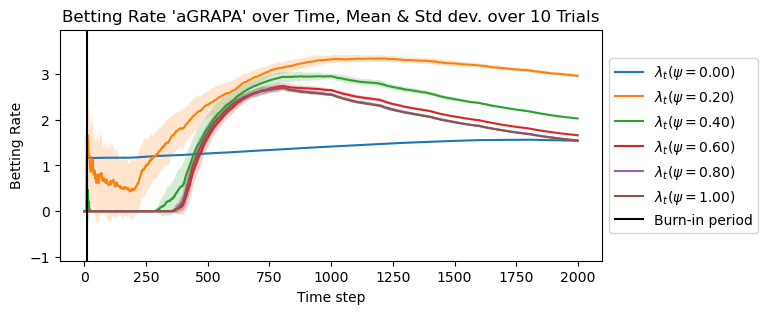

In [150]:
fixed_psi = torch.arange(0, 101, 20)

plt.figure(figsize=(7, 3))
for f_p in fixed_psi:
    bets_mean = stream_bets[:, :, f_p].mean(dim=0).numpy()
    bets_std = stream_bets[:, :, f_p].std(dim=0).numpy()
    plt.plot(bets_mean, label=fr"$\lambda_t(\psi = {psi_cand[f_p]:.2f})$")
    plt.fill_between(range(T), 
        bets_mean - bets_std, 
        bets_mean + bets_std, 
        alpha=0.2
    )
    
plt.axvline(burn_in, color='black', linestyle='-', label="Burn-in period")

plt.title(f"Betting Rate '{betting_type}' over Time, Mean & Std dev. over {R} Trials")
plt.xlabel("Time step")
plt.ylabel("Betting Rate")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# plt.xlim(0, 800)
# plt.ylim(0, 0.5)

# savefig("batch_1", f"bets_{betting_type}_over_time")
plt.show()

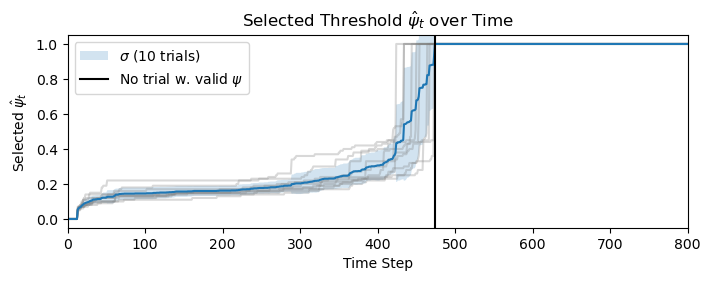

In [155]:
plt.figure(figsize=(8, 2.5))

for tr in range(R):
    plt.plot(range(T), psi_select[tr], color='gray', alpha=0.3)

psi_select_mean = psi_select.mean(dim=0).numpy()
psi_select_std = psi_select.std(dim=0).numpy()
plt.plot(range(T), psi_select_mean)
plt.fill_between(range(T), 
        psi_select_mean - psi_select_std, 
        psi_select_mean + psi_select_std, 
        alpha=0.2, label=rf"$\sigma$ ({R} trials)"
    )


plt.axvline(torch.where(psi_cs_size.mean(dim=0) == 0)[0][0], color='black', linestyle='-', label="No trial w. valid $\psi$")

plt.xlabel(r"Time Step")
plt.ylabel("Selected $\hat{\psi}_t$")
plt.title("Selected Threshold $\hat{\psi}_t$ over Time")

plt.xlim(0, 800)
plt.ylim(-0.05, 1.05)

# plt.grid(True)
plt.legend()

(0.0, 10.5)

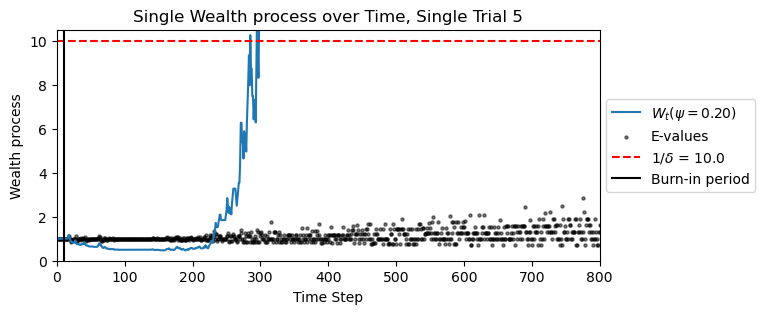

In [153]:
trial = 5
fixed_psi = 0.2
idx = torch.where(psi_cand == fixed_psi)[0].item()

plt.figure(figsize=(7, 3))
plt.plot(stream_eprocess[trial, :, idx].numpy(), label=fr"$W_t(\psi = {fixed_psi:.2f})$")
plt.scatter(torch.arange(1, T+1), stream_eval[trial, :, idx], label="E-values", color="black", s=5, alpha=0.5)
plt.axhline(1/delta, color='red', linestyle='--', label=rf"$1/\delta$ = {1/delta}")
plt.axvline(burn_in, color='black', linestyle='-', label="Burn-in period")

plt.title(f"Single Wealth process over Time, Single Trial {trial}")
plt.xlabel("Time Step")
plt.ylabel("Wealth process")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlim(0, 800)
plt.ylim(0, 1/delta+0.5)
# plt.ylim(0, 2)

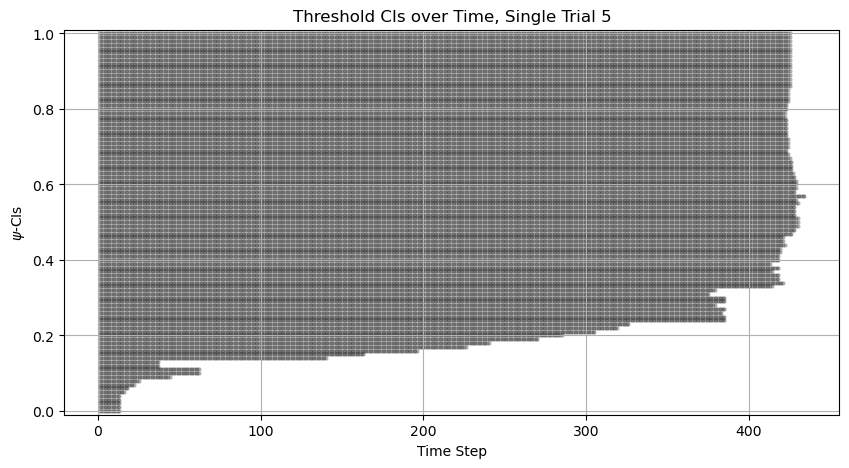

In [154]:
# Generate scatter plot for valid psi values over time steps
plt.figure(figsize=(10, 5))
for t, valid_psi in enumerate(psi_cs[trial], start=1):
    plt.scatter([t] * len(valid_psi[0]), valid_psi[0], alpha=0.2, color="black", s=5)

plt.title(rf"Threshold CIs over Time, Single Trial {trial}")
plt.xlabel("Time Step")
plt.ylabel(r"$\psi$-CIs")
plt.ylim(-0.01, 1.01)
plt.grid(True)

#### OLD CODE

In [96]:
# # Find the first occurrence where consecutive indices exist in `tau_emp`
# def find_first_consecutive(tau_emp, sequence_length=30):
#     for i in range(len(tau_emp) - sequence_length + 1):
#         # Check if there is a consecutive sequence of specified length
#         if torch.all(tau_emp[i:i + sequence_length] == torch.arange(tau_emp[i], tau_emp[i] + sequence_length)):
#             return tau_emp[i]  # Return the starting index of the first robust crossing
#     return None  # Return None if no such sequence is found

# def get_stopping_time_risk(risk, eps, burn_in=0):
#     tau_emp = torch.where(risk[burn_in:] >= eps)[0]
#     if len(tau_emp) == 0:
#         tau = T
#     else:
#         first_robust_crossing = find_first_consecutive(tau_emp)
#         if first_robust_crossing is None:
#             # tau = tau_emp.min() + burn_in
#             tau = T
#         else:
#             tau = first_robust_crossing
#     return tau

# def get_stopping_time_eprocess(e_process, eps):
#     tau_eval = torch.where(e_process >= 1/eps)[0]
#     if len(tau_eval) == 0:
#         tau = T
#     else:
#         tau = tau_eval.min()
#     return tau

# def get_bets(betting_type, T, burn_in=0):
#     stream_lam = torch.zeros(T)
    
#     if betting_type == "unit_bet":
#         stream_lam = torch.ones(T)
#     else:
#         raise ValueError(f"Unknown betting type: {betting_type}")
    
#     stream_lam = torch.cat([torch.zeros(burn_in), stream_lam[:T - burn_in]])
#     return stream_lam

In [97]:
# stream_lam = get_bets("unit_bet", T, burn_in=0)
# stream_eval = torch.ones(T) + stream_lam * (stream_loss - eps)
# stream_eprod = torch.cumprod(stream_eval, dim=1)

# stream_lam.shape, stream_eval.shape, stream_eprod.shape

In [98]:
# psi_stop_times = torch.tensor([get_stopping_time_eprocess(stream_eprocess[i], eps).item() for i in range(len(psi_cand))])
# risk_stop_times = torch.tensor([get_stopping_time_risk(stream_risk[i], eps, burn_in=0).item() for i in range(len(psi_cand))])
# detection_delay = psi_stop_times - risk_stop_times

# psi_stop_times, risk_stop_times, detection_delay
# # detection_delay